In [51]:
from pathlib import Path
import sys
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
import importlib
from Modeling.models.ROM import ROM
from Modeling.models.FE1 import PiezoBeamFE, frf_sweep, solve_newmark
# if 'ROM' in dir():
# 	importlib.reload(sys.modules['ROM'])

import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd


In [52]:

#%%

K_i = 0; K_p = 0.02; K_c = 0
t_end = 0.01
f0 = 1000; f1 = 8000
N = 40
j_exc = 30

def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
params = PiezoBeamParams()
params.zeta_p = 0.0151/5
params.zeta_q = 0.0392/5
rom = ROM(params, N=N)
interface_idx = 12
beta = 0.3
# # ======= K_p sweep in frequency domain =======

ki0 = 4000
ki2 = ki0 / (1 - beta)**2 
ki1 = ki0 / (1 + beta)**2 
S = rom.S
K_i = np.zeros(S)
for i in range(S):
	if i < interface_idx:
		K_i[i] = ki1 if i % 2 == 0 else ki2
	else:
		K_i[i] = ki2 if (i - interface_idx) % 2 == 0 else ki1

np.set_printoptions(precision=0, suppress=True)
print("K_i:", K_i, )
#%%
# x_eval = np.linspace(0, rom.p.L_b, 1000)
# x0 = np.zeros(2*N + 2*S)


t_eval = np.arange(0, t_end, 1/f1/20)
x_eval = np.linspace(0, rom.p.L_b, 500)

results = rom.run_time_sim(v_exc=v_exc, j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i, t_end=t_end, x_eval=x_eval, t_eval=t_eval)
t = results['t']
veloc = results['veloc']
freq = results['freq']
Y = results['Y']
X = results['X']
FRF = results['FRF']

freq_modal, vel_mag, disp_mag, veloc_frq = rom.frequency_response(j_exc=j_exc, K_c=K_c, K_p=K_p, K_i=K_i,
										w=np.linspace(f0, f1, 200)*2*np.pi, x_eval=x_eval)


K_i: [2367. 8163. 2367. 8163. 2367. 8163. 2367. 8163. 2367. 8163. 2367. 8163.
 8163. 2367. 8163. 2367. 8163. 2367. 8163. 2367. 8163. 2367. 8163. 2367.
 8163. 2367. 8163. 2367. 8163. 2367. 8163.]


First 5 natural frequencies (FE): [  5.  33.  93. 183. 302.] Hz
Running time domain simulation with FE model...
Computing frequency response (FE)...
FE frequency response complete.


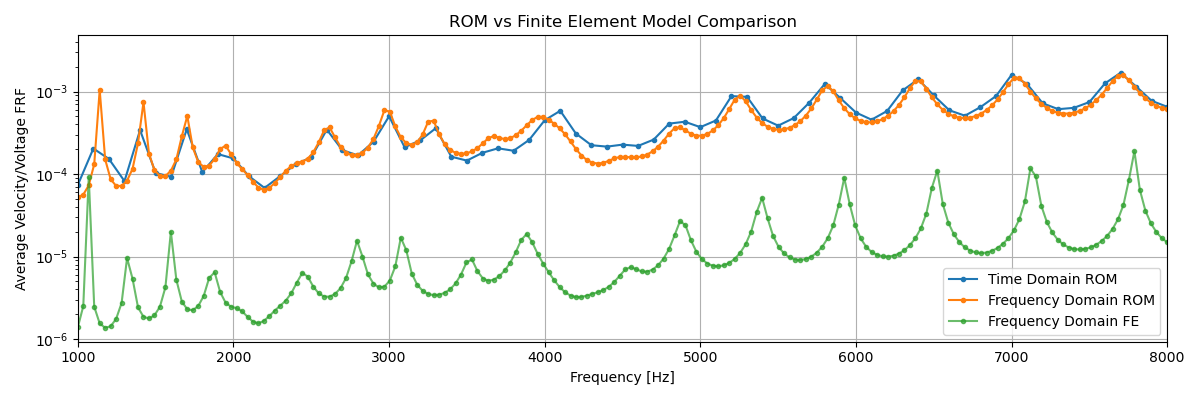

In [56]:
%matplotlib widget
# =================== Finite Element Analysis ===================
# Setup FE model with same parameters
params_fe = PiezoBeamParams()
params_fe.zeta_p = 0.0151/5
params_fe.zeta_q = 0.0392/5

# Create FE model
fe = PiezoBeamFE(params_fe)

# Perform eigenanalysis
freq_fe, omega_fe, Phi_fe = fe.eigen_analysis()
print(f"First 5 natural frequencies (FE): {freq_fe[:5]} Hz")

# Build ODE system for FE model
# Note: K_i in FE is scalar (applied to all patches except excitation)
# We'll use the mean K_i value from ROM setup
K_i_mean = np.mean(K_i)

ode_fe = fe.build_ode_system(
    j_exc=j_exc,
    A_exc=50.0,
    f0=f0,
    f1=f1,
    t_end=t_end,
    R_c=1e3,
    K_p=K_p,
    K_i=K_i,
    K_c=K_c
)

# =================== Time Domain Simulation (FE) ===================
print("Running time domain simulation with FE model...")
dt = 1/(f1*20)
# t_fe, x_fe, x_dot_fe, x_ddot_fe = solve_newmark(
#     ode_fe,
#     dt=dt,
#     t_end=t_end,
#     beta=0.25,
#     gamma=0.5,
#     newton_tol=1e-9,
#     newton_maxiter=5
# )

# # Extract mechanical DOFs (displacement)
N_mech = ode_fe.N_mech
# u_fe = x_fe[:, :N_mech]  # all mechanical DOFs
# w_fe = u_fe[:, ::2]      # transverse displacement only

# # Compute average velocity
# v_fe = x_dot_fe[:, :N_mech]
# v_w_fe = v_fe[:, ::2]    # transverse velocity only
# v_avg_fe = np.mean(np.abs(v_w_fe), axis=1)

# # FFT for frequency response
# dt_fe = t_fe[1] - t_fe[0]
# freq_fft_fe = np.fft.fftfreq(len(t_fe), d=dt_fe)
# V_fft_fe = np.fft.fft(v_avg_fe)

# # Keep positive frequencies
# idx_pos_fe = (freq_fft_fe >= f0) & (freq_fft_fe <= f1)
# freq_fft_fe_pos = freq_fft_fe[idx_pos_fe]
# V_mag_fe = np.abs(V_fft_fe[idx_pos_fe]) / (50.0)  # normalize by excitation amplitude

# print(f"FE time simulation complete. {len(t_fe)} time steps.")

# =================== Frequency Domain Analysis (FE) ===================
print("Computing frequency response (FE)...")
omega_sweep = np.linspace(f0, f1, 200) * 2 * np.pi
X_frf_fe = frf_sweep(ode_fe, omega_sweep)

# Extract mechanical response
U_frf_fe = X_frf_fe[:, :N_mech]
w_frf_fe = U_frf_fe[:, ::2]

# Compute average velocity magnitude
vel_mag_fe = np.abs(w_frf_fe * (omega_sweep[:, np.newaxis] * 1j)).mean(axis=1) / 50.0
freq_sweep_fe = omega_sweep / (2 * np.pi)

print("FE frequency response complete.")

# =================== Plot Comparison: ROM vs FE ===================
plt.figure(figsize=(12, 4))
plt.semilogy(freq, FRF, '.-', linewidth=1.5, label='Time Domain ROM')
plt.semilogy(freq_modal, vel_mag, '.-', label='Frequency Domain ROM')
# plt.semilogy(freq_fft_fe_pos, V_mag_fe, 's-', linewidth=1.5, markersize=3, label='Time Domain FE', alpha=0.7)
plt.semilogy(freq_sweep_fe, vel_mag_fe, 'o-', markersize=3, label='Frequency Domain FE', alpha=0.7)
plt.legend()
plt.xlim([f0, f1])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Average Velocity/Voltage FRF")
plt.title("ROM vs Finite Element Model Comparison")
plt.grid(True)
plt.tight_layout()
plt.show()


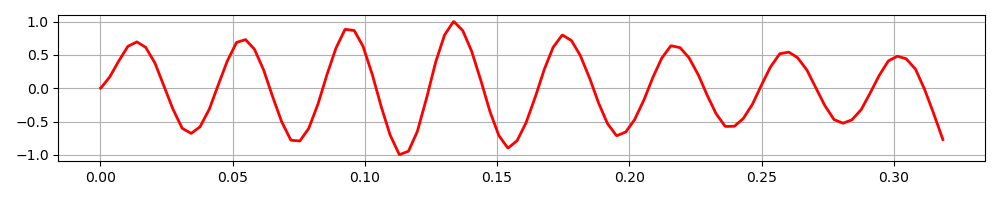

ki0=  4000 beta=  0.3 f_target=  3525.0


In [57]:
# =================== FE Mode shape at single frequency ===================
# Uses FE frequency response to plot the spatial mode shape (velocity) at a chosen frequency

# Try to reuse the same target frequency as ROM cell, fallback if missing

f_target = 3525.0  # Hz

# Ensure FE objects exist
assert 'fe' in globals() and 'ode_fe' in globals(), "FE model not initialized. Run the FE analysis cell first."

# Reduced mechanical displacement DOFs correspond to nodes 1..end (node 0 clamped)
x_coords_fe = fe.x_nodes[1:]

# If FE FRF sweep exists, sample nearest; otherwise compute single-frequency FRF
if 'w_frf_fe' in globals() and 'freq_sweep_fe' in globals():
    idx_near = np.argmin(np.abs(freq_sweep_fe - f_target))
    w_hat_nodes = w_frf_fe[idx_near, :]  # displacement at reduced nodes (complex)
    omega_t = 2*np.pi*freq_sweep_fe[idx_near]
else:
    omega_t = 2*np.pi*f_target
    X_single = frf_sweep(ode_fe, np.array([omega_t]))[0]
    N_mech = ode_fe.N_mech
    w_hat_nodes = X_single[:N_mech][::2]

# Velocity (complex) = i*omega * displacement
v_hat_nodes = 1j * omega_t * w_hat_nodes

# Plot real part, normalized for shape clarity (sign preserved)
v_plot = np.real(v_hat_nodes)
max_abs = np.max(np.abs(v_plot))
if max_abs > 0:
    v_plot = v_plot / max_abs

plt.figure(figsize=(10, 2))
plt.plot(x_coords_fe, v_plot, 'r-', linewidth=2)
# plt.xlabel('Position along beam [m]')
# plt.ylabel('Normalized velocity (real)')
# plt.title(f'FE Mode shape at {f_target:.1f} Hz')
plt.grid(True)
plt.tight_layout()
plt.show()
print("ki0= ", ki0, 'beta= ', beta, 'f_target= ', f_target)